In [1]:
# 1. Hazırlık ve Ortam Ayarları
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Görsel stil ve boyut standardı
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

# Rastgelelik sabitleme
np.random.seed(42)

# Pandas görüntüleme ayarları
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# 2. Örnek  Veri Seti Oluşturma
n = 1000
sehirler_tutarsiz = [
    "İstanbul",
    "istanbul",
    "İSTANBUL ",
    "Ankara",
    "ANKARA",
    " ankara",
    "İzmir",
    "izmir",
]

df = pd.DataFrame(
    {
        "yas": np.random.randint(18, 70, size=n),
        "gelir": np.random.normal(35000, 8000, size=n).round(2),
        "sehir": np.random.choice(sehirler_tutarsiz, size=n),
        "abonelik_tipi": np.random.choice(
            ["Standart", "Premium", "Platin"], size=n, p=[0.6, 0.3, 0.1]
        ),
        "kayit_tarihi": pd.date_range(
            start="2024-01-01", periods=n, freq="h"
        ).strftime("%Y-%m-%d"),
        "aylik_harcama": np.random.uniform(100, 3000, size=n).round(2),
        "memnuniyet_puani": np.random.choice(
            [1, 2, 3, 4, 5], size=n, p=[0.05, 0.15, 0.3, 0.35, 0.15]
        ),
        "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2]),
    }
)

In [4]:
# 3. Kasıtlı "Kirli Veri" Enjeksiyonu
# Eksik değerler
df.loc[np.random.choice(df.index, 40, replace=False), "gelir"] = np.nan
df.loc[np.random.choice(df.index, 30, replace=False), "yas"] = np.nan
df.loc[
    np.random.choice(df.index, 25, replace=False), "memnuniyet_puani"
] = np.nan

# Gelir sütununa aşırı uç değerler (Outlier)
df.loc[np.random.choice(df.index, 5, replace=False), "gelir"] = (
    np.random.uniform(500000, 1000000, 5)
)

# Yaş sütununa mantık dışı değerler (-5, 150)
df.loc[np.random.choice(df.index, 4, replace=False), "yas"] = [-5, -2, 135, 150]

# Yinelenen (Duplicate) satırlar ekleme
duplikeler = df.sample(15)
df = pd.concat([df, duplikeler], ignore_index=True)

In [5]:
# 4. veri setine bakıs
print("Satır ve Sütun Sayısı:", df.shape)

df.info()

print("\nİlk 3 Satır:\n", df.head(3))
print("\nSon 3 Satır:\n", df.tail(3))
print("\nRastgele 3 Satır:\n", df.sample(3))

Satır ve Sütun Sayısı: (1015, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   yas               984 non-null    float64
 1   gelir             975 non-null    float64
 2   sehir             1015 non-null   object 
 3   abonelik_tipi     1015 non-null   object 
 4   kayit_tarihi      1015 non-null   object 
 5   aylik_harcama     1015 non-null   float64
 6   memnuniyet_puani  990 non-null    float64
 7   churn             1015 non-null   int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 63.6+ KB

İlk 3 Satır:
     yas    gelir     sehir abonelik_tipi kayit_tarihi  aylik_harcama  \
0 56.00 22148.43    ANKARA      Standart   2024-01-01         165.04   
1 69.00 36627.71  istanbul      Standart   2024-01-01        1145.24   
2 46.00 28949.19    Ankara      Standart   2024-01-01        2372.84   

   memnuniyet_puani  chu

                  Eksik_Sayisi  Eksik_Yuzdesi(%)  Benzersiz_Sayi
yas                         31              3.05              56
gelir                       40              3.94             960
sehir                        0              0.00               8
abonelik_tipi                0              0.00               3
kayit_tarihi                 0              0.00              42
aylik_harcama                0              0.00             999
memnuniyet_puani            25              2.46               5
churn                        0              0.00               2


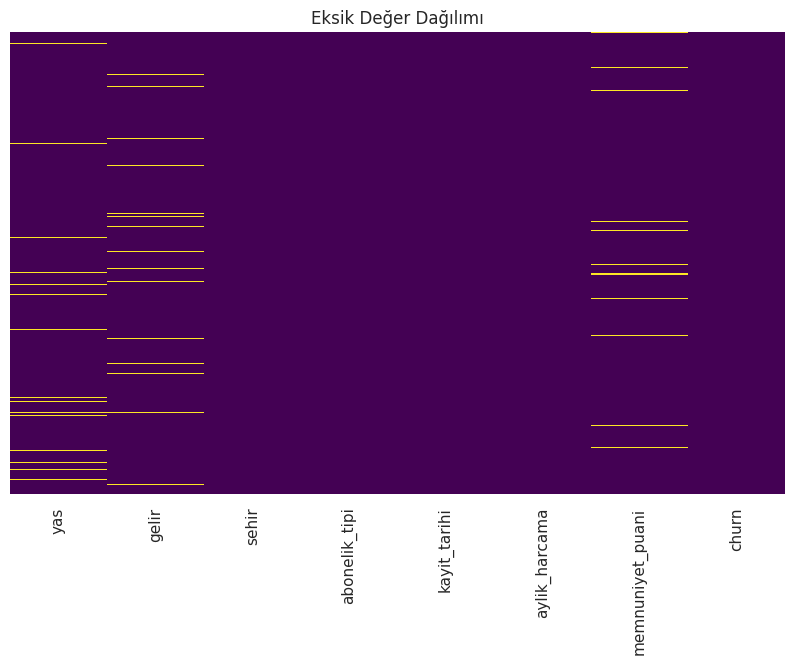

In [6]:
# 5. Eksik Değer Analizi
# özet tablo (Eksik Sayısı, Benzersiz Sayısı, Eksik Yüzdesi)
eksik_ozet = pd.DataFrame(
    {
        "Eksik_Sayisi": df.isna().sum(),
        "Eksik_Yuzdesi(%)": (df.isna().mean() * 100).round(2),
        "Benzersiz_Sayi": df.nunique(),
    }
)
print(eksik_ozet)

# heatmap
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Eksik Değer Dağılımı")
plt.show()

In [7]:
# 6. Tekrarlanan kayıt
print("Toplam Duplicate Satır Sayısı:", df.duplicated().sum())

Toplam Duplicate Satır Sayısı: 15


In [8]:
# 7. Kategorik Veri Temizliği
# Tutarsız yazımların dağılımı
print(df["sehir"].value_counts(dropna=False))

# Küçük harfe çevirme ve baştaki/sondaki boşlukları kırpma
df["sehir"] = df["sehir"].str.strip().str.lower()
print("\nTemizlik Sonrası Şehir Dağılımı:\n", df["sehir"].value_counts())

sehir
Ankara       151
İstanbul     135
 ankara      133
İSTANBUL     126
ANKARA       124
izmir        120
İzmir        119
istanbul     107
Name: count, dtype: int64

Temizlik Sonrası Şehir Dağılımı:
 sehir
ankara       408
i̇stanbul    261
izmir        120
i̇zmir       119
istanbul     107
Name: count, dtype: int64


In [9]:
# 8. Mantık Dışı (Anomali) Değerlerin Tespiti
anomaliler = df[(df["yas"] < 0) | (df["yas"] > 100)]
print("Anomali Yaş Değerleri:\n", anomaliler[["yas"]])

Anomali Yaş Değerleri:
        yas
181 150.00
640  -5.00
782  -2.00
992 135.00


In [10]:
# 9. Betimsel İstatistikler
# Sayısal sütunların temel istatistikleri
print(df.describe())

# Çarpıklık skew, Basıklık kurt
sayisal_kolonlar = df.select_dtypes(include=[np.number])
print("\nÇarpıklık (Skewness):\n", sayisal_kolonlar.skew())
print("\nBasıklık (Kurtosis):\n", sayisal_kolonlar.kurt())

         yas     gelir  aylik_harcama  memnuniyet_puani   churn
count 984.00    975.00        1015.00            990.00 1015.00
mean   43.83  39486.99        1520.79              3.40    0.20
std    15.79  56329.13         832.71              1.06    0.40
min    -5.00  11829.96         100.09              1.00    0.00
25%    31.00  30178.59         778.94              3.00    0.00
50%    44.00  35572.53        1519.24              3.00    0.00
75%    56.00  40679.85        2219.51              4.00    0.00
max   150.00 966066.96        2998.72              5.00    1.00

Çarpıklık (Skewness):
 yas                 0.40
gelir              14.08
aylik_harcama       0.02
memnuniyet_puani   -0.29
churn               1.50
dtype: float64

Basıklık (Kurtosis):
 yas                  1.91
gelir              205.04
aylik_harcama       -1.18
memnuniyet_puani    -0.52
churn                0.26
dtype: float64


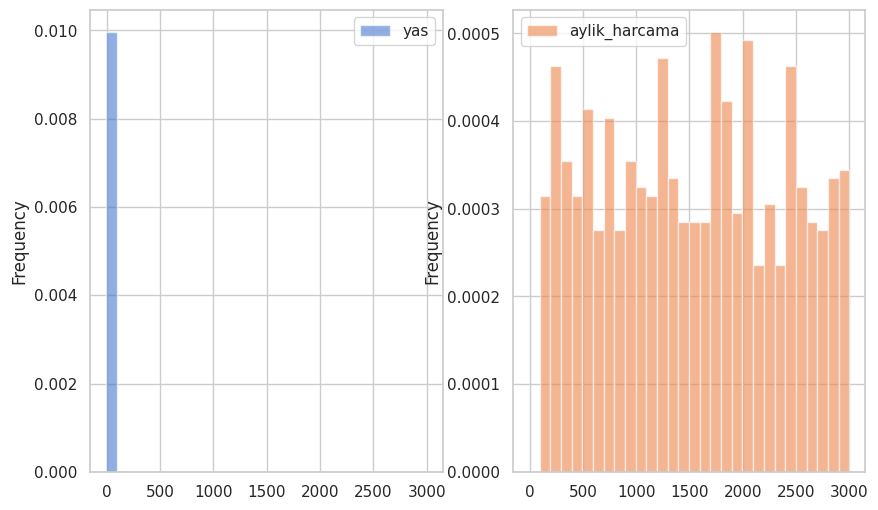

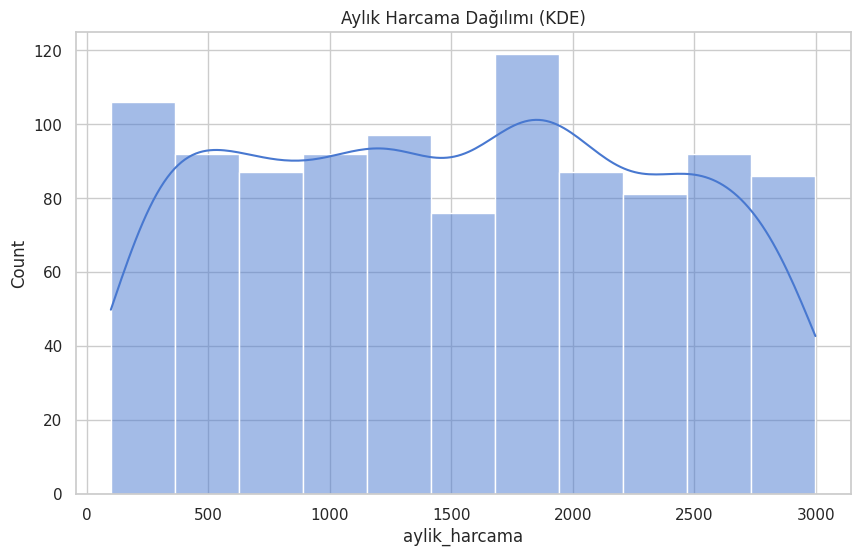

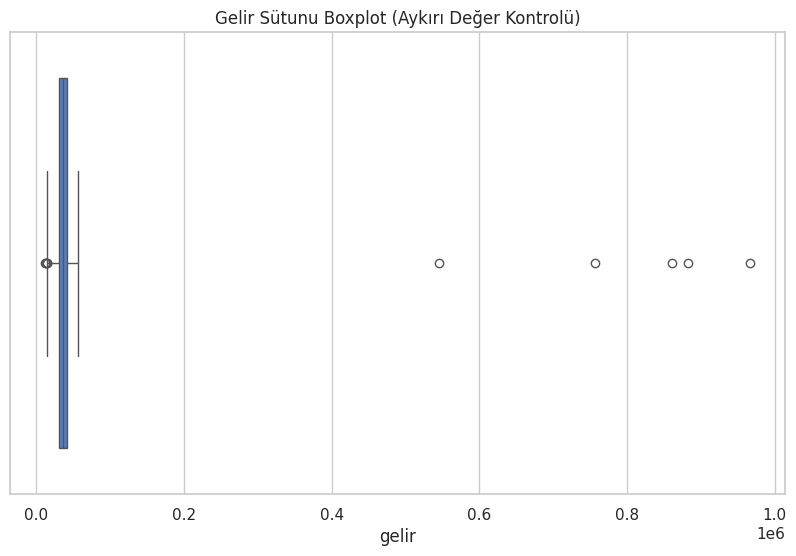

In [11]:
# 10. Dağılım Görselleştirmeleri
# Histogram ve Yoğunluk Eğrisi KDE
sayisal_kolonlar[["yas", "aylik_harcama"]].plot(
    kind="hist", subplots=True, layout=(1, 2), density=True, alpha=0.6, bins=30
)
plt.show()

# Alternatif KDE
sns.histplot(df["aylik_harcama"], kde=True)
plt.title("Aylık Harcama Dağılımı (KDE)")
plt.show()

# Aykırı değerler için Kutu Grafiği  BoxPlot
sns.boxplot(x=df["gelir"])
plt.title("Gelir Sütunu Boxplot (Aykırı Değer Kontrolü)")
plt.show()

In [12]:
# 11. Kategorik Değişken Analizi
for sutun in ["sehir", "abonelik_tipi", "memnuniyet_puani", "churn"]:
    print(f"\n--- {sutun} Yüzdesel Dağılımı (%) ---")
    print((df[sutun].value_counts(normalize=True, dropna=False) * 100).round(2))


--- sehir Yüzdesel Dağılımı (%) ---
sehir
ankara      40.20
i̇stanbul   25.71
izmir       11.82
i̇zmir      11.72
istanbul    10.54
Name: proportion, dtype: float64

--- abonelik_tipi Yüzdesel Dağılımı (%) ---
abonelik_tipi
Standart   59.21
Premium    31.33
Platin      9.46
Name: proportion, dtype: float64

--- memnuniyet_puani Yüzdesel Dağılımı (%) ---
memnuniyet_puani
4.00   31.72
3.00   31.23
5.00   15.37
2.00   14.78
1.00    4.43
NaN     2.46
Name: proportion, dtype: float64

--- churn Yüzdesel Dağılımı (%) ---
churn
0   80.00
1   20.00
Name: proportion, dtype: float64


Korelasyon Matrisi:
                    yas  gelir  aylik_harcama  memnuniyet_puani  churn
yas               1.00  -0.03           0.07              0.05  -0.01
gelir            -0.03   1.00          -0.00             -0.04  -0.04
aylik_harcama     0.07  -0.00           1.00             -0.04   0.00
memnuniyet_puani  0.05  -0.04          -0.04              1.00  -0.01
churn            -0.01  -0.04           0.00             -0.01   1.00


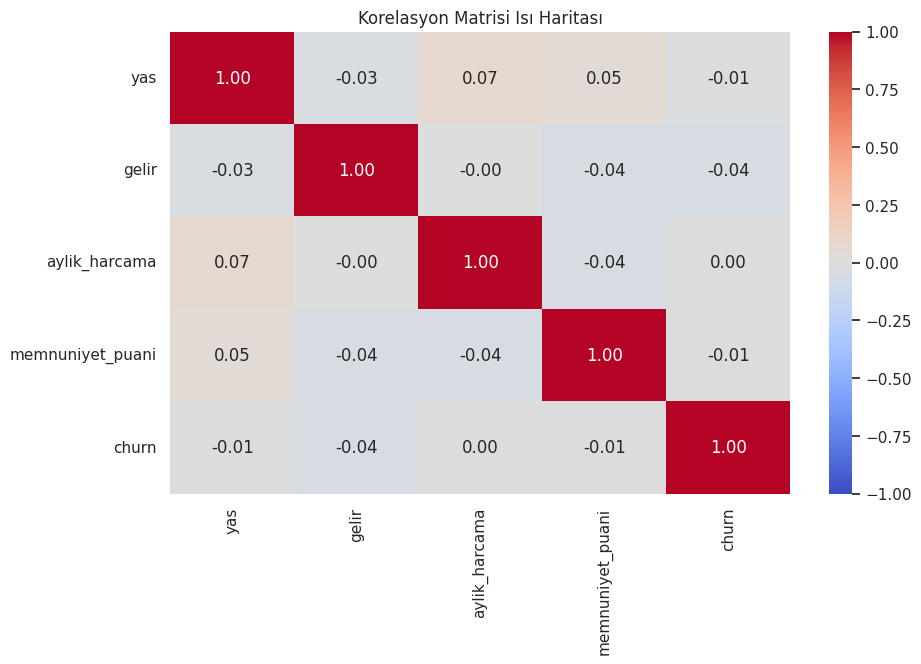

In [13]:
# 12. Korelasyon Analizi
# Korelasyon matrisi
korelasyon = sayisal_kolonlar.corr()
print("Korelasyon Matrisi:\n", korelasyon)

# Heatmap
sns.heatmap(korelasyon, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Korelasyon Matrisi Isı Haritası")
plt.show()